In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pickle
import mplhep as hep
import matplotlib.pyplot as plt
import yaml
import math
from tqdm import tqdm
plt.style.use(hep.style.CMS)
import uproot3 as uproot
import itertools
import os
import importlib.util
import sys
from array import array
import matplotlib.colors as mcolors
import gc
from typing import Iterable, Tuple, Dict, Any, Optional, List
import glob

In [2]:
# Sample loading 

In [3]:
# 2223
with open("Boost_GluGlutoHH_kl-1p00_kt-1p00_c2-0p00_2223.pkl", 'rb') as handle:
    Signal2223_batch0 =  pd.read_pickle(handle)
    Signal2223_batch0["valid"] = 1
with open("Boost_GluGlutoHH_kl-1p00_kt-1p00_c2-0p00_batch4_2223.pkl", 'rb') as handle:
    Signal2223_batch4 =  pd.read_pickle(handle)
    Signal2223_batch4["valid"] = 0
with open("Boost_GluGlutoHH_kl-1p00_kt-1p00_c2-0p00_batch5_2223.pkl", 'rb') as handle:
    Signal2223_patch5 =  pd.read_pickle(handle)
    Signal2223_patch5["valid"] = 0
Signal2223 = pd.concat([Signal2223_batch0, Signal2223_batch4, Signal2223_patch5], ignore_index = True)

/tmp/ipykernel_1073/915751473.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Signal2223_batch0["valid"] = 1
/tmp/ipykernel_1073/915751473.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Signal2223_batch4["valid"] = 0
/tmp/ipykernel_1073/915751473.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.co

In [4]:
with open("Boost_bbHtoGG_2223.pkl", "rb") as handle:
    bbH2223 = pd.read_pickle(handle)
with open("Boost_ttHtoGG_2223.pkl", "rb") as handle:
    ttH2223 = pd.read_pickle(handle)
with open("Boost_GluGluHtoGG_2223.pkl", "rb") as handle:
    ggH2223 = pd.read_pickle(handle)
with open("Boost_VHtoGG_2223.pkl", "rb") as handle:
    VH2223 = pd.read_pickle(handle)
with open("Boost_VBFHtoGG_2223.pkl", "rb") as handle:
    VBFH2223 = pd.read_pickle(handle)

In [5]:
with open("Boost_TTGG_2223.pkl", "rb") as handle:
    TTGG2223 = pd.read_pickle(handle)
with open("Boost_TTG-1Jets_PTG-100to200_2223.pkl", "rb") as handle:
    TTG100_2223 = pd.read_pickle(handle)
with open("Boost_TTG-1Jets_PTG-200_2223.pkl", "rb") as handle:
    TTG200_2223 = pd.read_pickle(handle)

TTG = pd.concat([TTGG2223, TTG100_2223, TTG200_2223], ignore_index = True)

In [6]:
with open("Boost_GGJets_MGG-80_2223.pkl", "rb") as handle:
    GGJ2223 = pd.read_pickle(handle)
with open("Boost_GJet_PT-20to40_DoubleEMEnriched_MGG-80_2223.pkl", "rb") as handle:
    GJ20_2223 = pd.read_pickle(handle)
with open("Boost_GJet_PT-40_DoubleEMEnriched_MGG-80_2223.pkl", "rb") as handle:
    GJ40_2223 = pd.read_pickle(handle)
GJ2223 = pd.concat([GJ20_2223,GJ40_2223], ignore_index = True)

In [7]:
#

In [8]:
with open("Boost_GluGlutoHH_kl-1p00_kt-1p00_c2-0p00_2024.pkl", 'rb') as handle:
    Signal24_batch0 =  pd.read_pickle(handle)
    Signal24_batch0["valid"] = 1
with open("Boost_GluGlutoHH_kl-1p00_kt-1p00_c2-0p00_batch4_2024.pkl", 'rb') as handle:
    Signal24_batch4 =  pd.read_pickle(handle)
    Signal24_batch4["valid"] = 0
with open("Boost_GluGlutoHH_kl-1p00_kt-1p00_c2-0p00_batch5_2024.pkl", 'rb') as handle:
    Signal24_patch5 =  pd.read_pickle(handle)
    Signal24_patch5["valid"] = 0
Signal24 = pd.concat([Signal24_batch0, Signal24_batch4, Signal24_patch5], ignore_index = True)

In [9]:
with open("Boost_bbHtoGG_2024.pkl", "rb") as handle:
    bbH2024 = pd.read_pickle(handle)
with open("Boost_GluGluHtoGG_2024.pkl", "rb") as handle:
    ggH2024 = pd.read_pickle(handle)
with open("Boost_VBFHtoGG_2024.pkl", "rb") as handle:
    VBFH2024 = pd.read_pickle(handle)
with open("Boost_WmHtoGG_2024.pkl", "rb") as handle:
    WmH = pd.read_pickle(handle)
with open("Boost_WpHtoGG_2024.pkl", "rb") as handle:
    WpH = pd.read_pickle(handle)   
with open("Boost_ZHtoGG_2024.pkl", "rb") as handle:
    ZH = pd.read_pickle(handle) 
VH2024 = pd.concat([WmH,WpH,ZH], ignore_index=True)

In [10]:
with open("Boost_TTGG_2024.pkl", "rb") as handle:
    TTGG2024 = pd.read_pickle(handle)
with open("Boost_GGJets_MGG-80_2024.pkl", "rb") as handle:
    GGJ2024 = pd.read_pickle(handle)

In [11]:
#Make b-tagging cut
sample_list23={
    "signal23": Signal2223,
    "ggH23": ggH2223,
    "ttH23": ttH2223,
    "bbH23": bbH2223,
    "vH23" : VH2223,
    "vbfH23": VBFH2223,
    "GJ23": GJ2223,
    "GGJ23": GGJ2223,
    "TTG23": TTG}
    
sample_list24 = {
    "signal24": Signal24,
    "ggH24":ggH2024,
    "bbH24": bbH2024,
    "vH24" : VH2024,
    "vbfH24":VBFH2024,
    "GGJ24": GGJ2024,
    "TTG24": TTGG2024
}


In [14]:
def cut_sample(df):
    df.query("`b-tagging`>0", inplace=True)
    df.query("`fatjet_selected_tau21`<0.75", inplace=True)
    df.query("`fatjet_selected_pt`>300", inplace = True)

In [15]:
for name in sample_list23:
    cut_sample(sample_list23[name])
for name in sample_list24:
    cut_sample(sample_list24[name])

In [ ]:
features = [
    "lead_eta",
    "eta",
    "lead_mvaID",
    "sublead_mvaID",
    'Res_DNNpair_CosThetaStar_gg',
    'Res_DNNpair_CosThetaStar_CS',
    'Res_DNNpair_pholead_PtOverM',
    'Res_DNNpair_phosublead_PtOverM',
    'lead_sigmaE_over_E',
    'sublead_sigmaE_over_E',

    'n_leptons',
    'lepton1_pfIsoId',
    'lepton1_pt',
    'puppiMET_pt',
    'puppiMET_sumEt',

    'fatjet_selected_regmass',
    'fatjet_selected_tau21',
    'fatjet_selected_tau32',
    'b-tagging',
    'fatjet_selected_pt',

    'DeltaR_jg_min',
    'deltaEta_gg_fj',
    'deltaPhi_gg_fj',
    'deltaR_gg_fj',
    'n_jets',
    'n_fatjets',
    'n_fatjets_final'
]

In [18]:
event_variables = ["eventWeight", "erainfo", "mass", "valid", "fatjet_selected_tau_ratio", "fatjet_selected_genMatched_Hbb"]

In [19]:
Bkg_event_variables = ["eventWeight", "erainfo", "Type", "mass"]

In [20]:
Signal = pd.concat([Signal2223[BDT_variables+event_variables] , Signal24[BDT_variables+event_variables]], 
                   ignore_index = True)

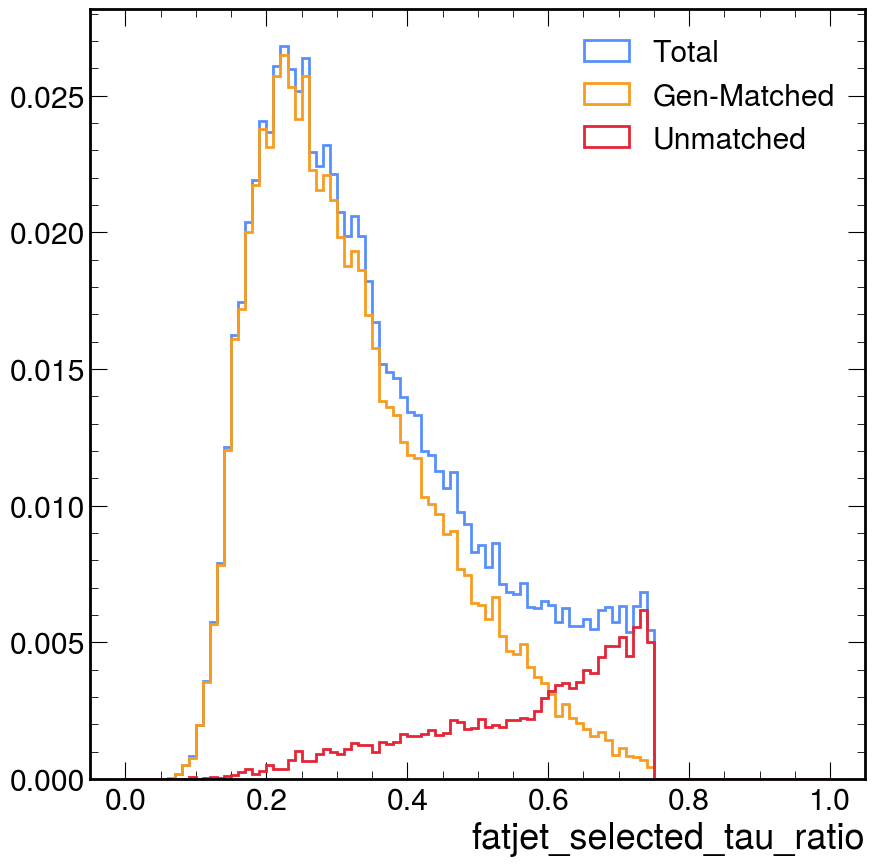

In [21]:
plt.hist(Signal["fatjet_selected_tau_ratio"], bins=100, range=(0,1), histtype = 'step', linewidth = 2,
         weights=Signal["eventWeight"], label="Total")
plt.hist(Signal[Signal["fatjet_selected_genMatched_Hbb"]==1]["fatjet_selected_tau_ratio"], bins=100, range=(0,1), histtype = 'step', linewidth = 2,
         weights=Signal[Signal["fatjet_selected_genMatched_Hbb"]==1]["eventWeight"], label="Gen-Matched")
plt.hist(Signal[Signal["fatjet_selected_genMatched_Hbb"]!=1]["fatjet_selected_tau_ratio"], bins=100, range=(0,1), histtype = 'step', linewidth = 2,
         weights=Signal[Signal["fatjet_selected_genMatched_Hbb"]!=1]["eventWeight"], label="Unmatched")
plt.legend()
plt.xlabel("fatjet_selected_tau_ratio")
plt.show()

In [22]:
ggH2223["Type"] = 3.0
ggH2024["Type"] = 3.0

bbH2223["Type"] = 4.0
bbH2024["Type"] = 4.0
ttH2223["Type"] = 4.0

VH2223["Type"] = 5.0
VH2024["Type"] = 5.0

VBFH2223["Type"] = 6.0
VBFH2024["Type"] = 6.0

GGJ2223["Type"] = 0.0
GGJ2024["Type"] = 0.0
GJ2223["Type"] = 0.0

TTG["Type"] = 1.0
TTGG2024["Type"]=1.0

In [23]:
fake_Signal = Signal[Signal["fatjet_selected_genMatched_Hbb"]!=1].copy()
Signal = Signal[Signal["fatjet_selected_genMatched_Hbb"]==1].copy()

In [24]:
Signal["Type"] = -1.0
fake_Signal["Type"] = 2.0

In [25]:
fake_Signal["eventWeight"] =  fake_Signal["eventWeight"]*((ggH2223["eventWeight"].sum()+ggH2024["eventWeight"].sum())/fake_Signal["eventWeight"].sum())

In [26]:
SingleH = pd.concat([ggH2223[BDT_variables+Bkg_event_variables],ttH2223[BDT_variables+Bkg_event_variables], 
                     bbH2223[BDT_variables+Bkg_event_variables], VH2223[BDT_variables+Bkg_event_variables], 
                     VBFH2223[BDT_variables+Bkg_event_variables], ggH2024[BDT_variables+Bkg_event_variables],
                     bbH2024[BDT_variables+Bkg_event_variables],  VH2024[BDT_variables+Bkg_event_variables],
                     VBFH2024[BDT_variables+Bkg_event_variables],
                     fake_Signal[BDT_variables+Bkg_event_variables]], ignore_index=True)

In [27]:
NonRes = pd.concat([GGJ2223[BDT_variables+Bkg_event_variables] , GGJ2024[BDT_variables+Bkg_event_variables],
                   GJ2223[BDT_variables+Bkg_event_variables], TTG[BDT_variables+Bkg_event_variables],
                   TTGG2024[BDT_variables+Bkg_event_variables]], ignore_index=True)

In [29]:
# _mass

In [30]:
Signal = Signal[Signal["fatjet_selected_pnetmass"]>30].copy()
SingleH = SingleH[SingleH["fatjet_selected_pnetmass"]>30].copy()
NonRes = NonRes[NonRes["fatjet_selected_pnetmass"]>30].copy()

In [31]:
#ttH
SingleH.loc[SingleH["Type"]==4,"eventWeight"] = SingleH[SingleH["Type"]==4]["eventWeight"] * 170/69

In [ ]:
Nonres_Weight = NonRes["eventWeight"].sum()
SingleH["balanced_Weight"] = (1/2) * SingleH["eventWeight"] * (Nonres_Weight/(SingleH["eventWeight"].sum()))
Signal["balanced_Weight"] = Signal["eventWeight"] * (Nonres_Weight/ Signal["eventWeight"].sum())

In [ ]:
NonRes["balanced_Weight"] = NonRes["eventWeight"]/2

In [94]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

In [95]:
def make_kfold_oof_xgb(
    Signal_df,
    SingleH_df,
    NonRes_df,
    BDT_variables,
    k=5,
    seed=42,
    params=None,
    num_boost_round=1500,
    early_stopping_rounds=50,
    use_abs_weight=True,
):
    """
    5-fold OOF:
      fold i: train on other folds, validate on fold i
      oof_score[val_idx] = model_i.predict(val)
    Returns:
      df_all (带label/weight/fold/oof_score)
      models (list of trained booster)
    """

    if params is None:
        params = {"objective": "binary:logistic", "max_depth": 3, "eta": 0.09, "gamma": 0.1}

    # 1) 组装全样本：Signal label=1, Bkg label=0
    sig = Signal_df.copy()
    sig["label"] = 1.0
    # 如果 Signal 没有 Type，给一个固定 Type 以便分层
    if "Type" not in sig.columns:
        sig["Type"] = -1

    bkg = pd.concat([NonRes_df.copy(), SingleH_df.copy()], ignore_index=True)
    bkg["label"] = 0.0
    if "Type" not in bkg.columns:
        raise ValueError("Background dataframe 需要有 'Type' 列来区分子类（NonRes/TT/SingleH子类等）。")

    df_all = pd.concat([sig, bkg], ignore_index=True)

    # 2) weight
    if "balanced_Weight" not in df_all.columns:
        raise ValueError("df_all 里找不到 'balanced_Weight' 列。")

    w = df_all["balanced_Weight"].to_numpy()
    if use_abs_weight:
        w = np.abs(w)

    # 清理 NaN/Inf（你之前也提到过要处理）
    w = np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)

    # 3) features -> numpy（确保 float）
    X = df_all[BDT_variables].to_numpy(dtype=np.float32)
    y = df_all["label"].to_numpy(dtype=np.float32)

    # 4) 构造分层 key：让 folds 同时保持 (label, Type) 的比例
    #    Signal Type=-1；Bkg Type=0/1/3/4/5/6...
    type_arr = df_all["Type"].fillna(-1).astype(int).to_numpy()
    strata = (y.astype(int) * 100 + (type_arr + 50)).astype(int)  # +50避免负数影响

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

    oof_score = np.full(len(df_all), np.nan, dtype=np.float32)
    fold_id = np.full(len(df_all), -1, dtype=int)
    models = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, strata)):
        fold_id[va_idx] = fold

        dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx], weight=w[tr_idx])
        dvalid = xgb.DMatrix(X[va_idx], label=y[va_idx], weight=w[va_idx])

        evals = [(dtrain, "train"), (dvalid, "valid")]

        booster = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=num_boost_round,
            evals=evals,
            early_stopping_rounds=early_stopping_rounds,
            verbose_eval=False,
        )

        # 用该 fold 的模型给“它的 valid fold”打分（这就是你要的 sample1 用 model1 输出）
        # 兼容不同 xgboost 版本：优先用 best_iteration
        if hasattr(booster, "best_iteration") and booster.best_iteration is not None:
            pred = booster.predict(dvalid, iteration_range=(0, booster.best_iteration + 1))
        else:
            pred = booster.predict(dvalid)

        oof_score[va_idx] = pred.astype(np.float32)
        models.append(booster)

        print(f"[fold {fold}] train={len(tr_idx)} valid={len(va_idx)} best_iter={getattr(booster,'best_iteration',None)}")

    df_all = df_all.copy()
    df_all["fold"] = fold_id
    df_all["oof_score"] = oof_score

    # sanity check：应该没有 NaN（每个样本都恰好被验证一次）
    n_nan = np.isnan(df_all["oof_score"].to_numpy()).sum()
    if n_nan != 0:
        raise RuntimeError(f"OOF 分数存在 NaN：{n_nan} 个样本没有被任何 fold 预测到（不应该发生）。")

    return df_all, models




In [134]:
BDT_variables

['eta',
 'lead_mvaID',
 'lead_sigmaE_over_E',
 'lepton1_mvaID',
 'lepton1_pfIsoId',
 'lepton1_pt',
 'Res_CosThetaStar_CS',
 'Res_CosThetaStar_gg',
 'pt',
 'puppiMET_pt',
 'puppiMET_sumEt',
 'sublead_mvaID',
 'sublead_sigmaE_over_E',
 'b-tagging',
 'fatjet_selected_pnetmass',
 'fatjet_selected_pt',
 'deltaR_g1_fj',
 'deltaR_g2_fj',
 'fatjet_selected_eta',
 'Res_DNNpair_HHbbggCandidate_mass',
 'Res_DNNpair_HHbbggCandidate_pt',
 'Res_DNNpair_HHbbggCandidate_eta',
 'fatjet_selected_tau21',
 'fatjet_selected_tau32']

In [96]:
# === 用法示例 ===
df_all, models = make_kfold_oof_xgb(
    Signal_df=Signal,
    SingleH_df=SingleH,
    NonRes_df=NonRes,
    BDT_variables=BDT_variables,
    k=5,
    seed=42,
    params={"objective": "binary:logistic", "max_depth": 3, "eta": 0.09, "gamma": 0.1},
    num_boost_round=1500,
    early_stopping_rounds=50,
    use_abs_weight=True,
)

[fold 0] train=224812 valid=56204 best_iter=886
[fold 1] train=224813 valid=56203 best_iter=333
[fold 2] train=224813 valid=56203 best_iter=515
[fold 3] train=224813 valid=56203 best_iter=605
[fold 4] train=224813 valid=56203 best_iter=325


In [97]:
# sample1 的分数（其实就是 fold==0 的那批，来自 model0 的输出）
#sample1_scores = df_all.loc[df_all["fold"] == 0, "oof_score"].to_numpy()

In [98]:
# import os

# save_dir = "xgb_yibo_models"
# os.makedirs(save_dir, exist_ok=True)

# for i, booster in enumerate(models):
#     booster.save_model(f"{save_dir}/xgb_fold{i}.json")

# print("Models saved.")

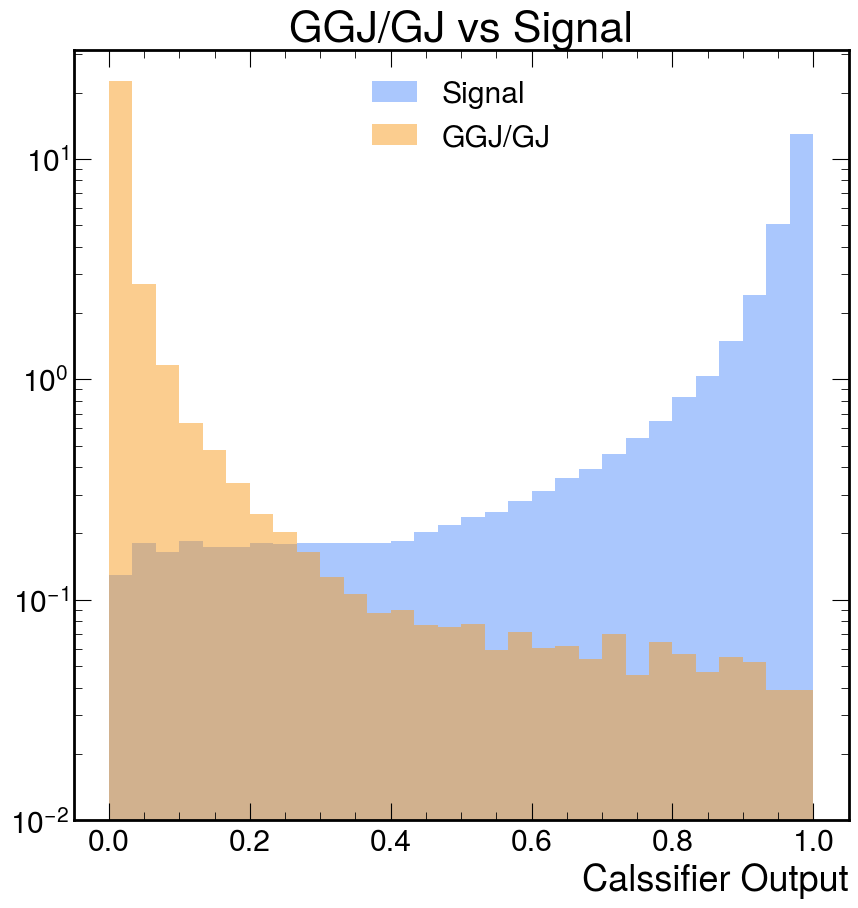

In [99]:
plt.hist(df_all[df_all["Type"]==-1]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="Signal", alpha=0.5)
plt.hist(df_all[df_all["Type"]==0]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="GGJ/GJ", alpha=0.5)
plt.yscale("log")
plt.ylim(1e-2,)
plt.xlabel("Calssifier Output")
plt.title("GGJ/GJ vs Signal")
plt.legend()
plt.show()

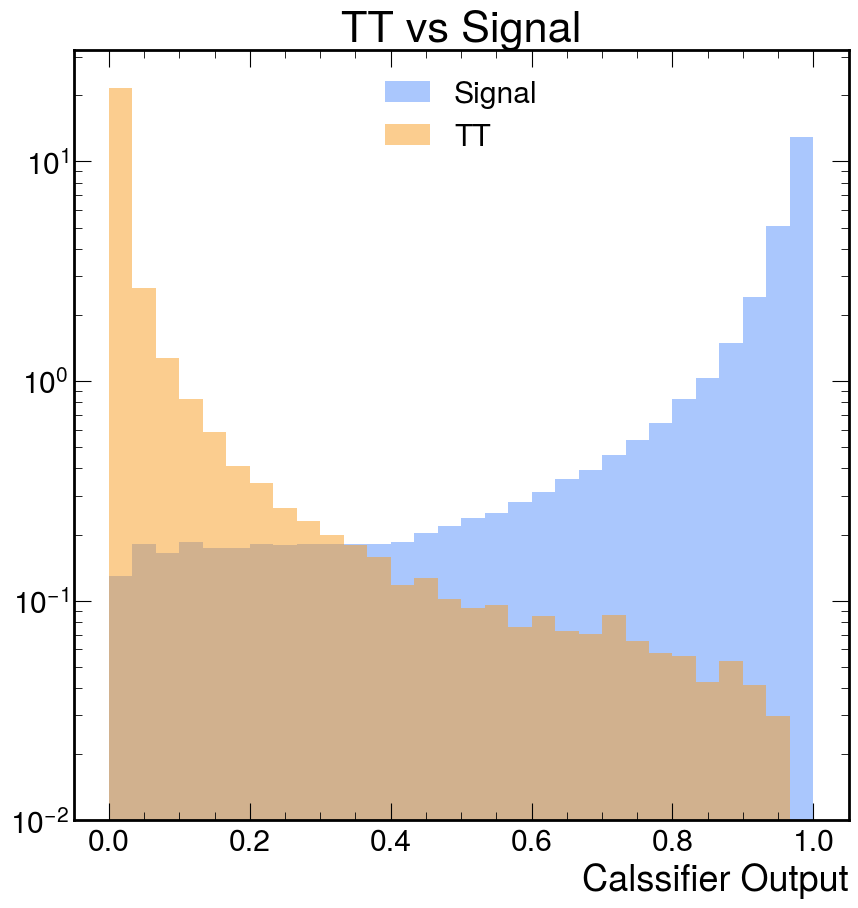

In [100]:
plt.hist(df_all[df_all["Type"]==-1]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="Signal", alpha=0.5)
plt.hist(df_all[df_all["Type"]==1]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="TT", alpha=0.5)
plt.yscale("log")
plt.ylim(1e-2,)
plt.xlabel("Calssifier Output")
plt.title("TT vs Signal")
plt.legend()
plt.show()

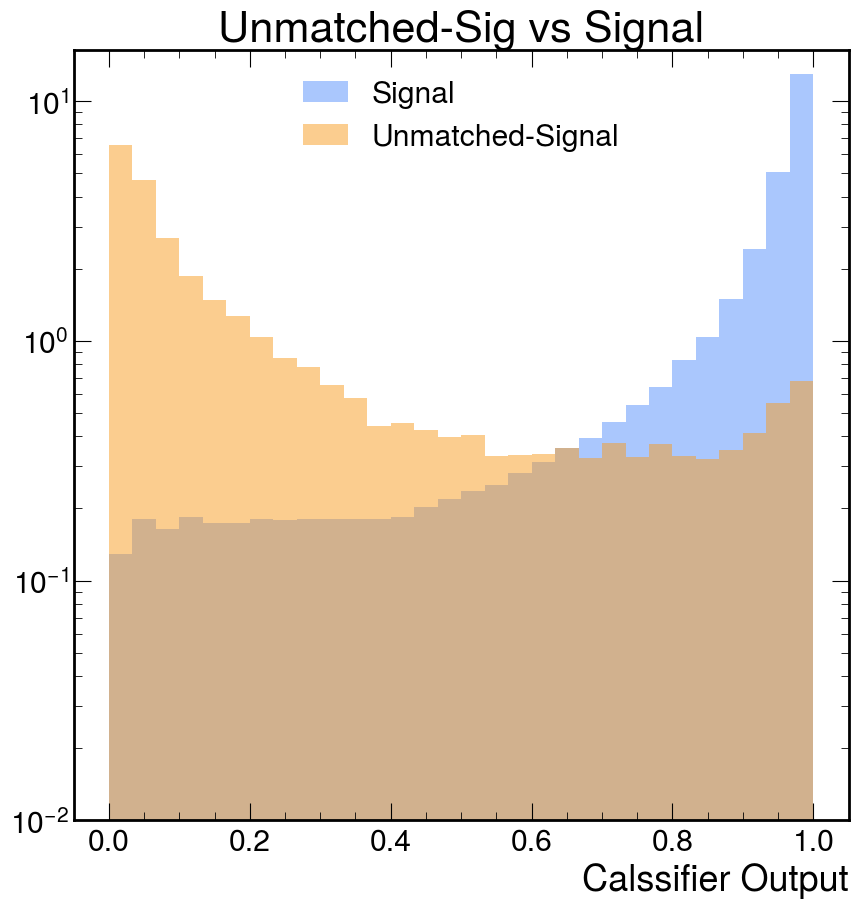

In [101]:
plt.hist(df_all[df_all["Type"]==-1]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="Signal", alpha=0.5)
plt.hist(df_all[df_all["Type"]==2]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="Unmatched-Signal", alpha=0.5)
plt.yscale("log")
plt.ylim(1e-2,)
plt.xlabel("Calssifier Output")
plt.title("Unmatched-Sig vs Signal")
plt.legend()
plt.show()

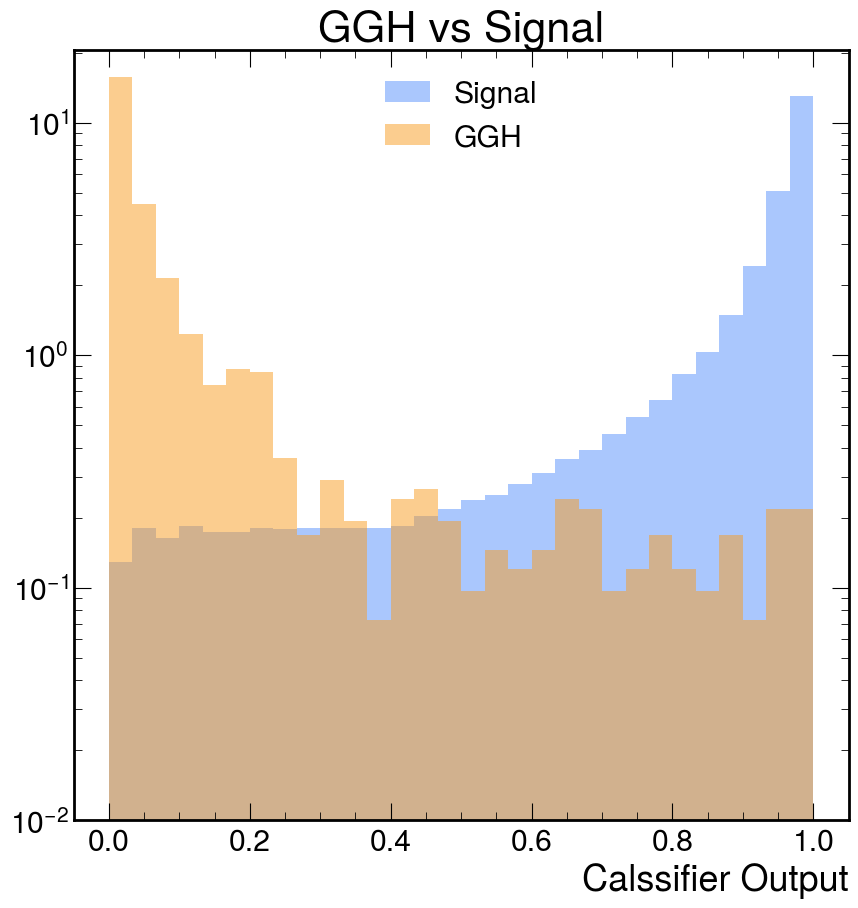

In [102]:
plt.hist(df_all[df_all["Type"]==-1]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="Signal", alpha=0.5)
plt.hist(df_all[df_all["Type"]==3]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="GGH", alpha=0.5)
plt.yscale("log")
plt.ylim(1e-2,)
plt.xlabel("Calssifier Output")
plt.title("GGH vs Signal")
plt.legend()
plt.show()

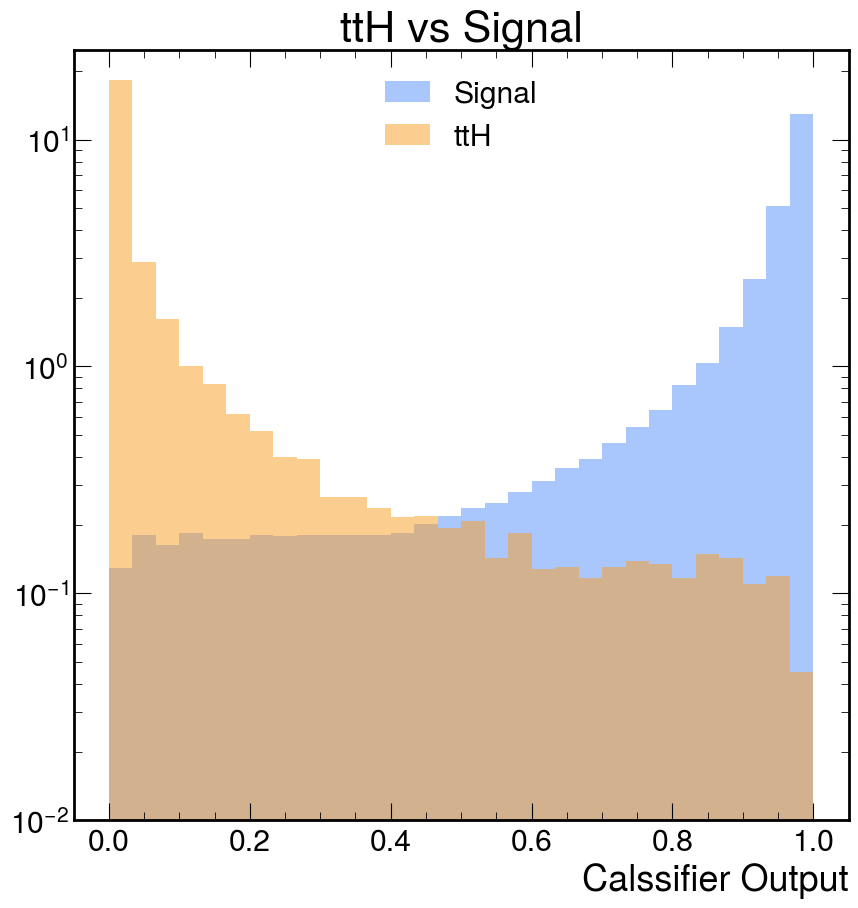

In [103]:
plt.hist(df_all[df_all["Type"]==-1]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="Signal", alpha=0.5)
plt.hist(df_all[df_all["Type"]==4]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="ttH", alpha=0.5)
plt.yscale("log")
plt.ylim(1e-2,)
plt.xlabel("Calssifier Output")
plt.title("ttH vs Signal")
plt.legend()
plt.show()

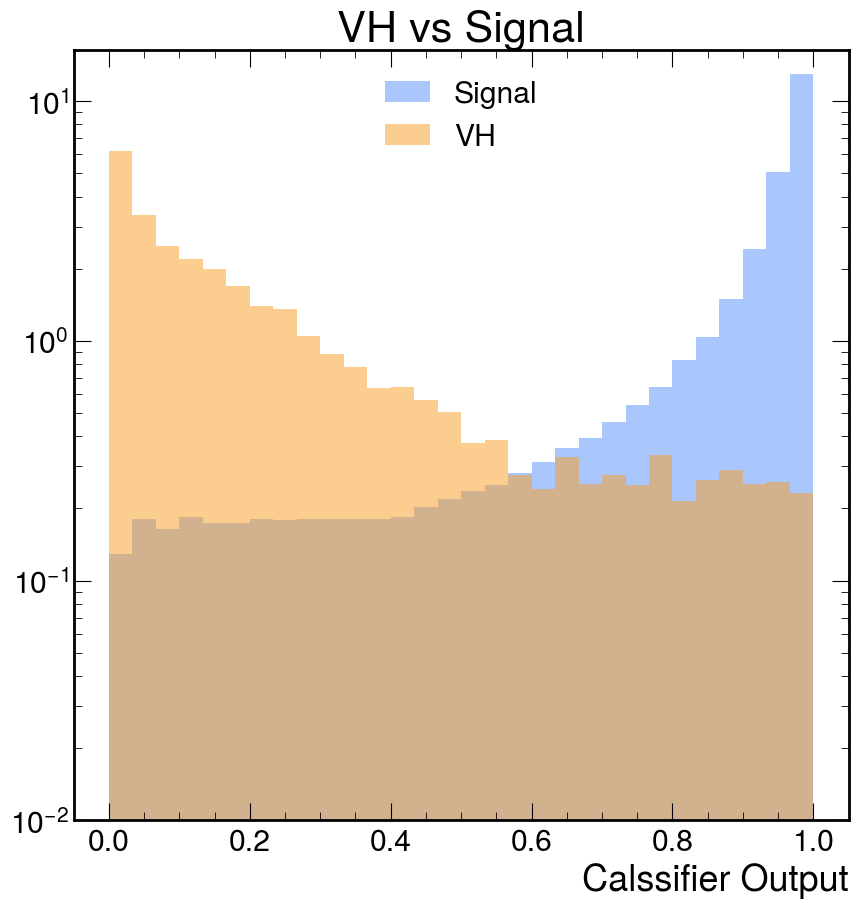

In [104]:
plt.hist(df_all[df_all["Type"]==-1]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="Signal", alpha=0.5)
plt.hist(df_all[df_all["Type"]==5]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="VH", alpha=0.5)
plt.yscale("log")
plt.ylim(1e-2,)
plt.xlabel("Calssifier Output")
plt.title("VH vs Signal")
plt.legend()
plt.show()

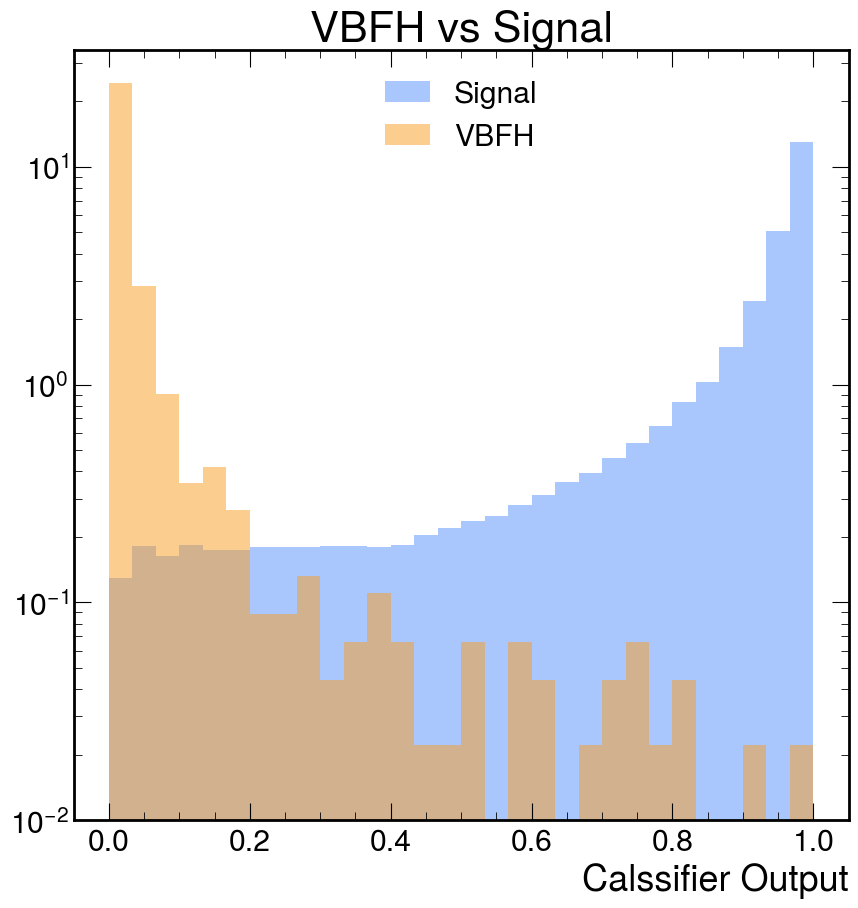

In [105]:
plt.hist(df_all[df_all["Type"]==-1]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="Signal", alpha=0.5)
plt.hist(df_all[df_all["Type"]==6]["oof_score"], bins=30, histtype="bar", range=(0,1), density=True, label="VBFH", alpha=0.5)
plt.yscale("log")
plt.ylim(1e-2,)
plt.xlabel("Calssifier Output")
plt.title("VBFH vs Signal")
plt.legend()
plt.show()

In [106]:
with open("Boost_2022_2223.pkl", "rb") as handle:
    Data2022 = pd.read_pickle(handle)
    Data2022["year"] = 2022
with open("Boost_2023_2223.pkl", "rb") as handle:
    Data2023 = pd.read_pickle(handle)
    Data2023["year"] = 2023
with open("Boost_2024_2024.pkl", "rb") as handle:
    Data2024 = pd.read_pickle(handle)
    Data2024["year"] = 2024
with open("Boost_2025_new_2024.pkl", "rb") as handle:
    Data2025 = pd.read_pickle(handle)
    Data2025["year"] = 2025

/tmp/ipykernel_1073/549402464.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Data2024["year"] = 2024
/tmp/ipykernel_1073/549402464.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Data2025["year"] = 2025


In [107]:
Data2223 = pd.concat([Data2022,Data2023], ignore_index = True)

In [108]:
Data2223['lead_sigmaE_over_E'] = Data2223['lead_energyErr'] / (Data2223['lead_pt'] * np.cosh(Data2223['lead_eta']))
Data2223['sublead_sigmaE_over_E'] = Data2223['sublead_energyErr'] / (Data2223['lead_pt'] * np.cosh(Data2223['lead_eta']))
Data2223['Res_pt_balance'] = Data2223['Res_HHbbggCandidate_pt'] / (Data2223['lead_pt'] + Data2223['sublead_pt'] + Data2223['Res_lead_bjet_pt'] + Data2223['Res_sublead_bjet_pt'])

In [109]:
Data2024['lead_sigmaE_over_E'] = Data2024['lead_energyErr'] / (Data2024['lead_pt'] * np.cosh(Data2024['lead_eta']))
Data2024['sublead_sigmaE_over_E'] = Data2024['sublead_energyErr'] / (Data2024['lead_pt'] * np.cosh(Data2024['lead_eta']))
Data2024['Res_pt_balance'] = Data2024['Res_HHbbggCandidate_pt'] / (Data2024['lead_pt'] + Data2024['sublead_pt'] + Data2024['Res_lead_bjet_pt'] + Data2024['Res_sublead_bjet_pt'])

/tmp/ipykernel_1073/2667393950.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Data2024['Res_pt_balance'] = Data2024['Res_HHbbggCandidate_pt'] / (Data2024['lead_pt'] + Data2024['sublead_pt'] + Data2024['Res_lead_bjet_pt'] + Data2024['Res_sublead_bjet_pt'])


In [110]:
Data2025['lead_sigmaE_over_E'] = Data2025['lead_energyErr'] / (Data2025['lead_pt'] * np.cosh(Data2025['lead_eta']))
Data2025['sublead_sigmaE_over_E'] = Data2025['sublead_energyErr'] / (Data2025['lead_pt'] * np.cosh(Data2025['lead_eta']))
Data2025['Res_pt_balance'] = Data2025['Res_HHbbggCandidate_pt'] / (Data2025['lead_pt'] + Data2025['sublead_pt'] + Data2025['Res_lead_bjet_pt'] + Data2025['Res_sublead_bjet_pt'])

/tmp/ipykernel_1073/3679844770.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Data2025['lead_sigmaE_over_E'] = Data2025['lead_energyErr'] / (Data2025['lead_pt'] * np.cosh(Data2025['lead_eta']))
/tmp/ipykernel_1073/3679844770.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Data2025['sublead_sigmaE_over_E'] = Data2025['sublead_energyErr'] / (Data2025['lead_pt'] * np.cosh(Data2025['lead_eta']))
/tmp/ipykernel_1073/3679844770.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

In [111]:
Data2223["b-tagging"] = 0
Data2223.loc[Data2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.95,"b-tagging"] = 5
Data2223.loc[(Data2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.9) & 
      (Data2223["fatjet_selected_particleNet_XbbVsQCD"]<0.95)  ,"b-tagging"] = 4
Data2223.loc[(Data2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.8) & 
      (Data2223["fatjet_selected_particleNet_XbbVsQCD"]<0.9)  ,"b-tagging"] = 3
Data2223.loc[(Data2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.6) & 
      (Data2223["fatjet_selected_particleNet_XbbVsQCD"]<0.8)  ,"b-tagging"] = 2
Data2223.loc[(Data2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.4) & 
      (Data2223["fatjet_selected_particleNet_XbbVsQCD"]<0.6)  ,"b-tagging"] = 1

In [112]:
Data2024["b-tagging"] = 0
Data2024.loc[Data2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.95,"b-tagging"] = 5
Data2024.loc[(Data2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.9) & 
      (Data2024["fatjet_selected_globalParT3_XbbVsQCD"]<0.95)  ,"b-tagging"] = 4
Data2024.loc[(Data2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.8) & 
      (Data2024["fatjet_selected_globalParT3_XbbVsQCD"]<0.9)  ,"b-tagging"] = 3
Data2024.loc[(Data2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.5) & 
      (Data2024["fatjet_selected_globalParT3_XbbVsQCD"]<0.8)  ,"b-tagging"] = 2
Data2024.loc[(Data2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.25) & 
      (Data2024["fatjet_selected_globalParT3_XbbVsQCD"]<0.5)  ,"b-tagging"] = 1

/tmp/ipykernel_1073/889516848.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Data2024["b-tagging"] = 0


In [113]:
Data2025["b-tagging"] = 0
Data2025.loc[Data2025["fatjet_selected_globalParT3_XbbVsQCD"]>=0.95,"b-tagging"] = 5
Data2025.loc[(Data2025["fatjet_selected_globalParT3_XbbVsQCD"]>=0.9) & 
      (Data2025["fatjet_selected_globalParT3_XbbVsQCD"]<0.95)  ,"b-tagging"] = 4
Data2025.loc[(Data2025["fatjet_selected_globalParT3_XbbVsQCD"]>=0.8) & 
      (Data2025["fatjet_selected_globalParT3_XbbVsQCD"]<0.9)  ,"b-tagging"] = 3
Data2025.loc[(Data2025["fatjet_selected_globalParT3_XbbVsQCD"]>=0.5) & 
      (Data2025["fatjet_selected_globalParT3_XbbVsQCD"]<0.8)  ,"b-tagging"] = 2
Data2025.loc[(Data2025["fatjet_selected_globalParT3_XbbVsQCD"]>=0.25) & 
      (Data2025["fatjet_selected_globalParT3_XbbVsQCD"]<0.5)  ,"b-tagging"] = 1

/tmp/ipykernel_1073/3903149161.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Data2025["b-tagging"] = 0


In [114]:
Data = pd.concat([Data2223[BDT_variables + ["mass", "year"]], Data2024[BDT_variables + ["mass", "year"]],
                 Data2025[BDT_variables + ["mass", "year"]]], ignore_index = True)

In [115]:
Data=Data[(Data["b-tagging"]>0)&(Data["fatjet_selected_pnetmass"]>30)&(Data["fatjet_selected_tau21"]<0.75)&
    (Data["fatjet_selected_pt"]>300)].copy()

In [116]:

def predict_5fold_mean(models, df, BDT_variables, output_margin=False):
    """
    用 5 个 fold 模型在 df 上预测，并对每个样本取平均。
    返回:
      mean_pred: shape (N,) 的 numpy array
      all_pred:  shape (5, N) 的 numpy array（可选用于看每个fold差异）
    """
    # features
    X = df[BDT_variables].to_numpy(dtype=np.float32)
    d = xgb.DMatrix(X)

    preds = []
    for m in models:
        best_it = getattr(m, "best_iteration", None)

        # early stopping 的模型：用 best_iteration 截断
        if best_it is not None:
            p = m.predict(
                d,
                iteration_range=(0, best_it + 1),
                output_margin=output_margin
            )
        else:
            p = m.predict(d, output_margin=output_margin)

        preds.append(p)

    all_pred = np.stack(preds, axis=0)   # (5, N)
    mean_pred = np.mean(all_pred, axis=0)
    median_pred = np.median(all_pred, axis=0) # (N,)
    return mean_pred, median_pred, all_pred



In [117]:

# ====== 用法示例 ======
# real_df: 你的真实 data dataframe（已经包含 BDT_variables 这些列）
# models: 你训练出来的 5 个模型 list

# 1) 取平均后的 score（binary:logistic -> P(signal) in (0,1)）
mean_score, median_score, fold_scores = predict_5fold_mean(models, Data, BDT_variables)

# 2) 写回 dataframe
Data = Data.copy()
Data["bdt_score_mean5"] = mean_score
Data["bdt_score_median5"] = median_score

# 3) 如果你也想保留每个 fold 的单独分数（方便检查稳定性）
for i in range(len(models)):
    Data[f"bdt_score_fold{i}"] = fold_scores[i]

# 4) sanity check
print("mean score range:", float(np.min(mean_score)), float(np.max(mean_score)))

mean score range: 3.370877311681397e-05 0.9793489575386047


In [130]:
df_all[(df_all["Type"]==-1)& (df_all["oof_score"]>0.8)&(df_all["valid"]==1) & 
    (df_all["mass"]<127)&(df_all["mass"]>122.5)]["eventWeight"].sum() 

0.21422149275504573

In [131]:
df_all[(df_all["Type"]>=3)& (df_all["oof_score"]>0.8)&
    (df_all["mass"]<127)&(df_all["mass"]>122.5)]["eventWeight"].sum() 

0.1841676886512478

In [132]:
df_all[(df_all["Type"]>=0) & (df_all["Type"]<2)& (df_all["oof_score"]>0.7)&
    (df_all["mass"]<180)&(df_all["mass"]>100)]["eventWeight"].sum() 

4.700641700834207

In [125]:
Data[(Data["bdt_score_mean5"]>0.7)&(((Data["mass"]<180)&(Data["mass"]>135))|((Data["mass"]<115)&(Data["mass"]>100)))][["mass","year","bdt_score_mean5"]]

,mass,year,bdt_score_mean5
15747,147.800986,2024,0.722510
20241,148.480375,2024,0.855217
21756,141.227712,2024,0.825494
23143,114.549296,2024,0.734624
28797,109.174143,2025,0.785312


In [133]:
#Data[(Data["bdt_score_mean5"]>0.7)&(Data["mass"]<135)&(Data["mass"]>115)][["mass","year","bdt_score_mean5"]]

In [140]:
from scipy.optimize import curve_fit
def exponential(x, A, k):
    return A * np.exp(k * x)
from scipy.integrate import quad

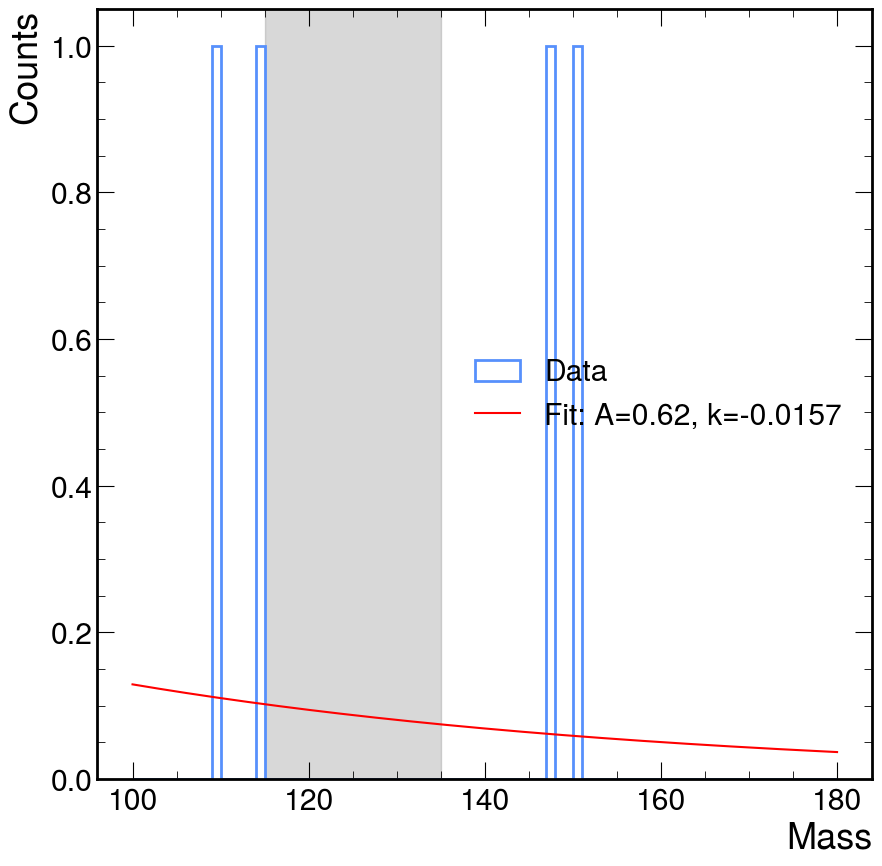

In [142]:
# Select data, excluding the 120-130 mass range for fitting
selected_data = Data[(((Data["mass"]>100)&(Data["mass"]<115))|((Data["mass"]>135)&(Data["mass"]<180)))
                &(Data["bdt_score_mean5"]>0.7)]
# Create histogram
counts, bin_edges, _ = plt.hist(
    selected_data["mass"].to_numpy(), 
    range=(100, 180), bins=80, histtype="step", 
    density=False, linewidth=2, label="Data"
)


# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Mask the range [120, 130] in the bin centers for fitting
mask = (bin_centers < 115) | (bin_centers >= 135)

# Fit exponential to the histogram data, excluding the 120-130 range
popt, pcov = curve_fit(exponential, bin_centers[mask], counts[mask], p0=(80, -0.01))

#Plot the fitted exponential function
x_fit = np.linspace(100, 180, 160)
y_fit = exponential(x_fit, *popt)
plt.plot(x_fit, y_fit, color='red', label=f'Fit: A={popt[0]:.2f}, k={popt[1]:.4f}')

# Add legend and labels
plt.xlabel("Mass")
plt.ylabel("Counts")
plt.legend()

# Highlight the masked region (120 to 130)
plt.axvspan(115, 135, color='gray', alpha=0.3, label="Masked region")

plt.show()

In [143]:
area, error = quad(exponential, 122.5, 127, args=tuple(popt))
print(f"Number of NonRes_Bkg in 122.5-127: {area:.4f}")

Number of NonRes_Bkg in 122.5-127: 0.3946


In [122]:
#Data[(Data["bdt_score_mean5"]>0.5)&(Data["mass"]<135)&(Data["mass"]>115)][["mass","year","bdt_score_mean5","b-tagging"]]

In [78]:
# Sideband Data 2223, 2024, 2025:  25, 57, 53

In [196]:
#0.243/(0.204+0.4)

In [190]:
#0.221/(0.4+0.124)

In [ ]:
# Model Compare

In [81]:
type_label_map = {
    0: "GGJ",
    1: "TTG",
    3: "ggH",
    4: "ttH/bbH",
    5: "VH",
    6: "VBFH",
}

In [82]:
import glob
import xgboost as xgb
import numpy as np

def load_xgb_models(model_path_or_pattern):
    """
    model_path_or_pattern:
      - "xgb_final.json"  -> 返回 [Booster]
      - "xgb_models/xgb_fold*.json" -> 返回 多个 Booster
    """
    paths = sorted(glob.glob(model_path_or_pattern))
    if len(paths) == 0:
        # 不是 pattern，就当成单文件
        paths = [model_path_or_pattern]

    models = []
    for p in paths:
        b = xgb.Booster()
        b.load_model(p)
        models.append(b)
    return models

def predict_with_models(models, X, use_best_iteration_if_available=True):
    """
    多模型：默认做 ensemble 平均
    单模型：就是它自己的输出
    """
    d = xgb.DMatrix(X)
    preds = np.zeros(X.shape[0], dtype=np.float32)

    for m in models:
        if use_best_iteration_if_available and hasattr(m, "best_iteration") and m.best_iteration is not None:
            p = m.predict(d, iteration_range=(0, m.best_iteration + 1))
        else:
            p = m.predict(d)
        preds += p.astype(np.float32)

    preds /= len(models)
    return preds

In [83]:
import pandas as pd
from sklearn.metrics import roc_auc_score

def auc_per_bkg_type(
    df_eval,
    score_col,
    type_label_map,
    weight_col="balanced_Weight",
    use_abs_weight=True,
):
    out = {}
    for t in sorted(type_label_map.keys()):
        mask = (df_eval["label"] == 1) | ((df_eval["label"] == 0) & (df_eval["Type"] == t))
        df_sub = df_eval.loc[mask]

        y = df_sub["label"].to_numpy()
        s = df_sub[score_col].to_numpy()

        if weight_col is None:
            auc = roc_auc_score(y, s)
        else:
            w = df_sub[weight_col].to_numpy()
            if use_abs_weight:
                w = np.abs(w)
            w = np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)
            auc = roc_auc_score(y, s, sample_weight=w)

        out[t] = auc
    return out

def compare_two_models_auc(
    df_eval,
    auc_A,
    auc_B,
    type_label_map,
    name_A="ModelA",
    name_B="ModelB",
):
    rows = []
    for t in sorted(type_label_map.keys()):
        rows.append({
            "Type": t,
            "Process": type_label_map[t],
            f"AUC({name_A})": auc_A[t],
            f"AUC({name_B})": auc_B[t],
            "Delta(B-A)": auc_B[t] - auc_A[t],
        })
    return pd.DataFrame(rows)

In [59]:
df_eval = df_all.copy()

In [60]:
# 读取模型A（比如 final）
models_A = load_xgb_models("xgb_models_pnetmass/xgb_fold*.json")

# 读取模型B（比如 5-fold 模型集合）
models_B = load_xgb_models("xgb_models/xgb_fold*.json")

# 取特征矩阵
X_eval = df_eval[BDT_variables].to_numpy(dtype=np.float32)

# 打分
df_eval["score_A"] = predict_with_models(models_A, X_eval)
df_eval["score_B"] = predict_with_models(models_B, X_eval)

In [61]:
aucA = auc_per_bkg_type(df_eval, "score_A", type_label_map, weight_col="balanced_Weight", use_abs_weight=True)
aucB = auc_per_bkg_type(df_eval, "score_B", type_label_map, weight_col="balanced_Weight", use_abs_weight=True)

cmp = compare_two_models_auc(df_eval, aucA, aucB, type_label_map, name_A="A", name_B="B")
print(cmp)

   Type  Process    AUC(A)    AUC(B)  Delta(B-A)
0     0      GGJ  0.984624  0.986308    0.001684
1     1      TTG  0.973815  0.981894    0.008078
2     3      ggH  0.971824  0.967213   -0.004611
3     4  ttH/bbH  0.961939  0.970687    0.008748
4     5       VH  0.954324  0.943856   -0.010467
5     6     VBFH  0.992041  0.984844   -0.007197


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_compare_per_type(
    df_eval,
    scoreA,
    scoreB,
    type_label_map,
    weight_col="balanced_Weight",
    use_abs_weight=True,
    logx=False,
):
    """
    df_eval 必须包含:
        label
        Type
        balanced_Weight
        scoreA
        scoreB
    """

    for t in sorted(type_label_map.keys()):

        mask = (df_eval["label"] == 1) | (
            (df_eval["label"] == 0) & (df_eval["Type"] == t)
        )

        df_sub = df_eval.loc[mask]

        y = df_sub["label"].to_numpy()

        sA = df_sub[scoreA].to_numpy()
        sB = df_sub[scoreB].to_numpy()

        w = df_sub[weight_col].to_numpy()
        if use_abs_weight:
            w = np.abs(w)
        w = np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)

        # Model A
        aucA = roc_auc_score(y, sA, sample_weight=w)
        fprA, tprA, _ = roc_curve(y, sA, sample_weight=w)

        # Model B
        aucB = roc_auc_score(y, sB, sample_weight=w)
        fprB, tprB, _ = roc_curve(y, sB, sample_weight=w)

        # ---- Plot ----
        plt.figure()

        plt.plot(fprA, tprA, label=f"Model A (AUC={aucA:.3f})", linewidth=2)
        plt.plot(fprB, tprB, label=f"Model B (AUC={aucB:.3f})", linewidth=2)
        plt.axhline(y=0.77, label="Working Cut")

        plt.plot([0, 1], [0, 1], "--", color="gray")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Signal vs {type_label_map[t]}")
        plt.legend()
        plt.grid(alpha=0.3)

        if logx:
            plt.xscale("log")

        plt.show()

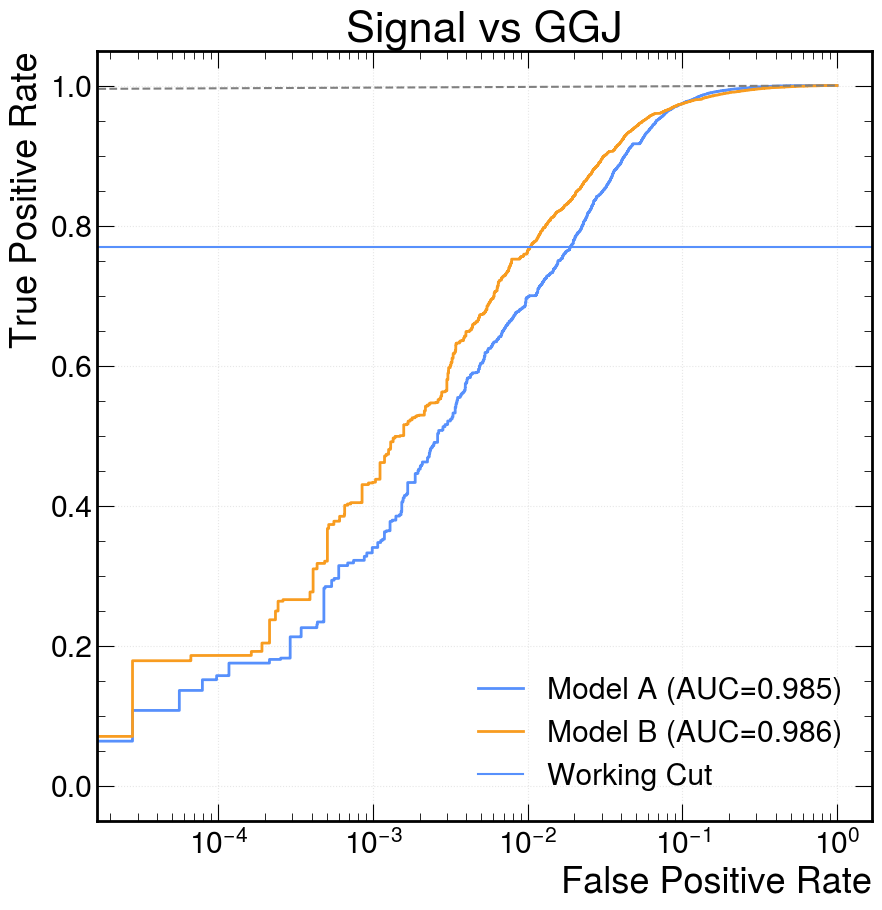

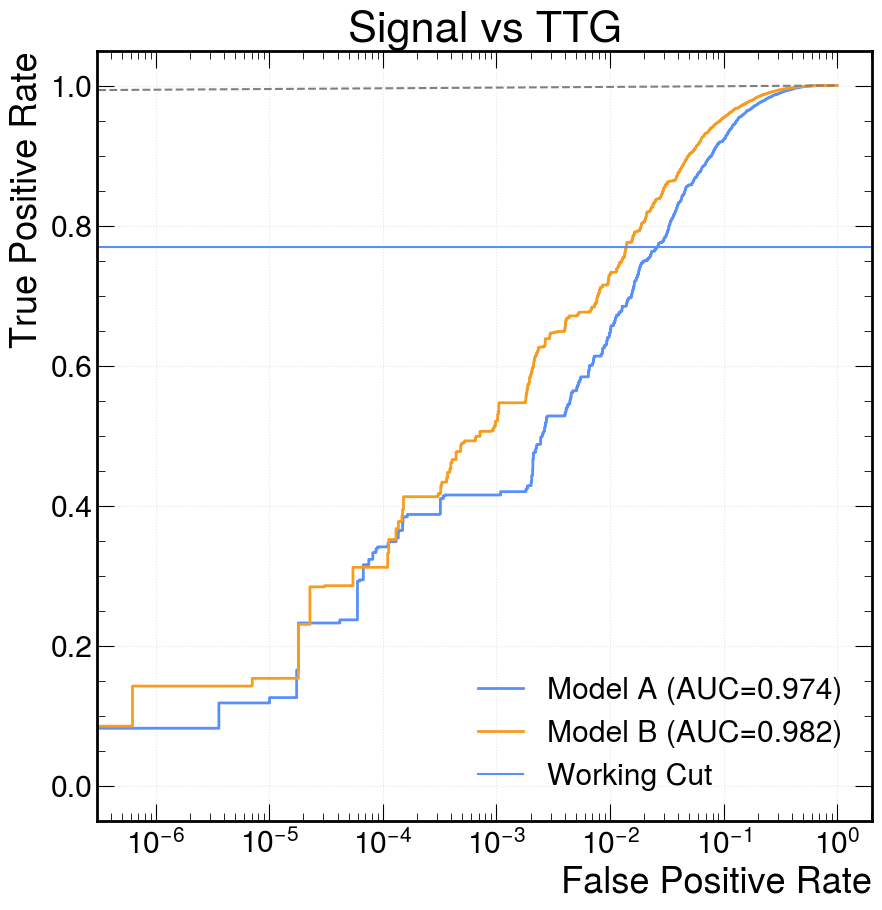

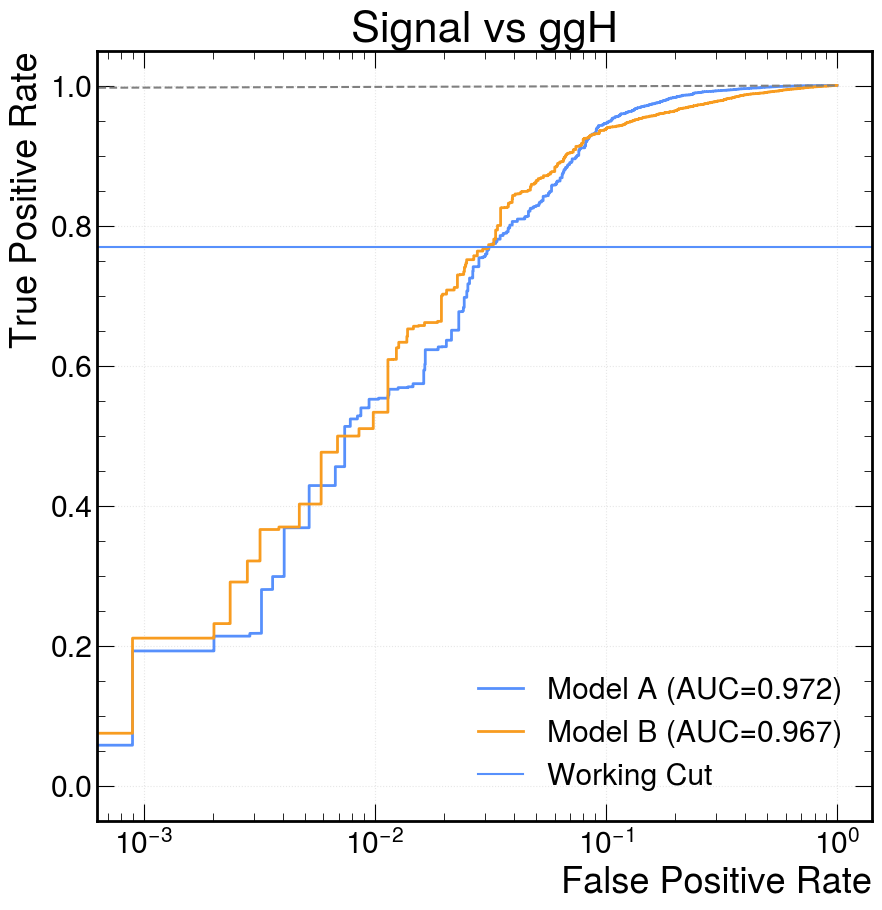

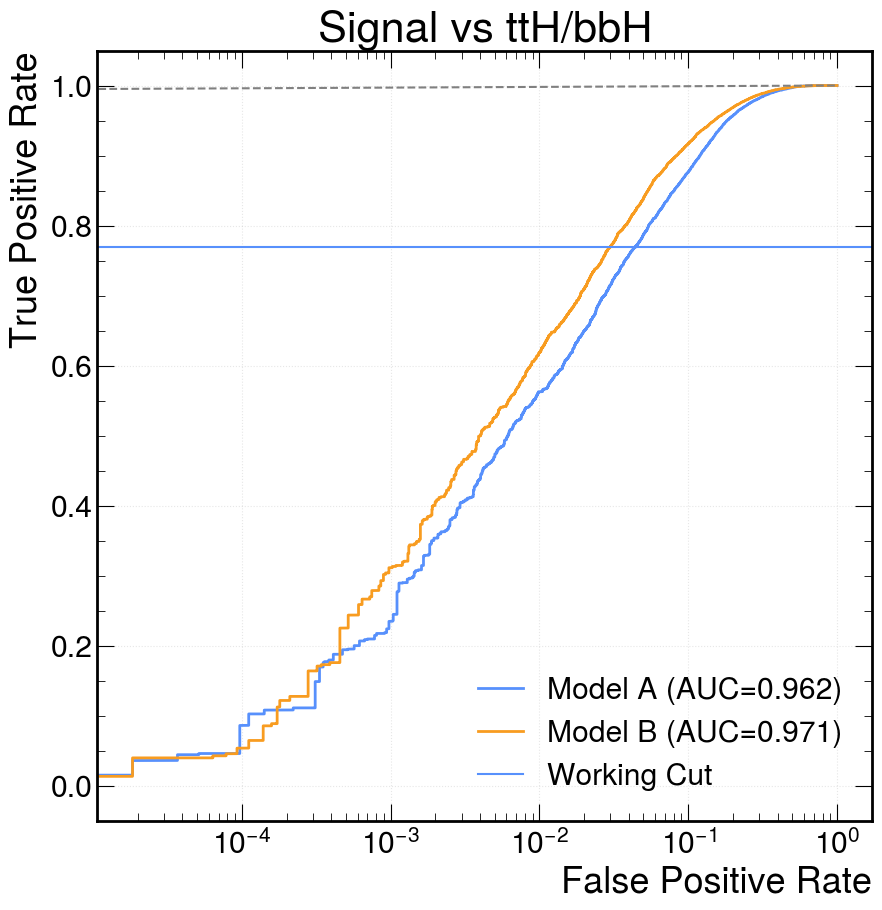

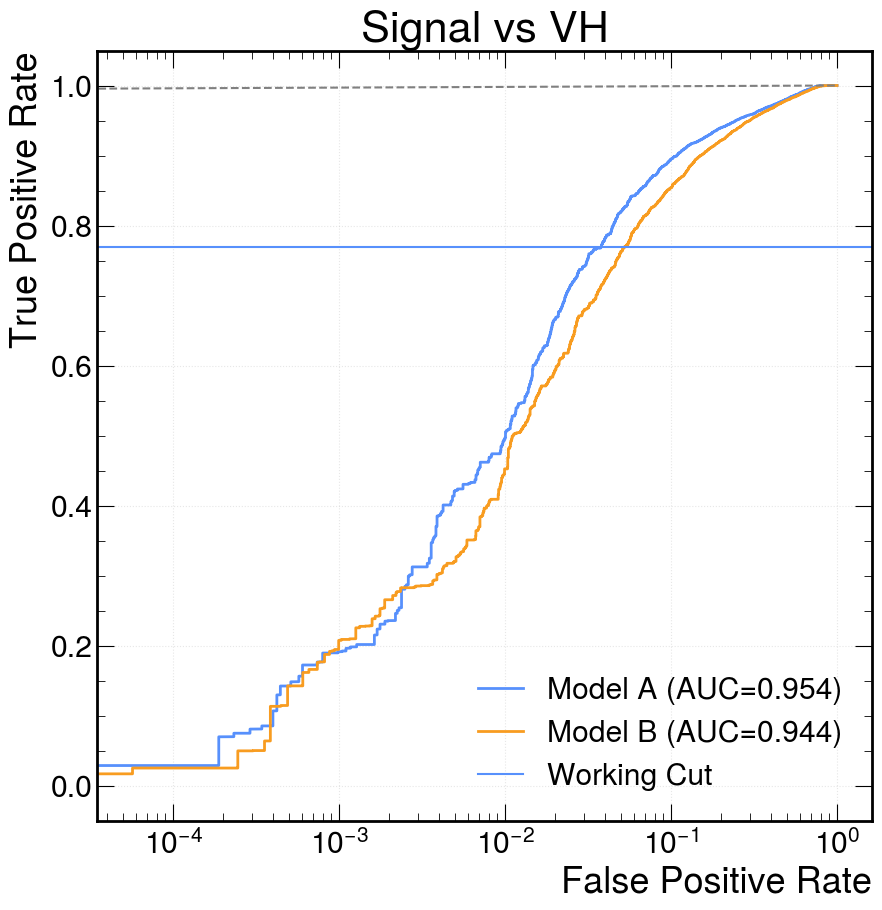

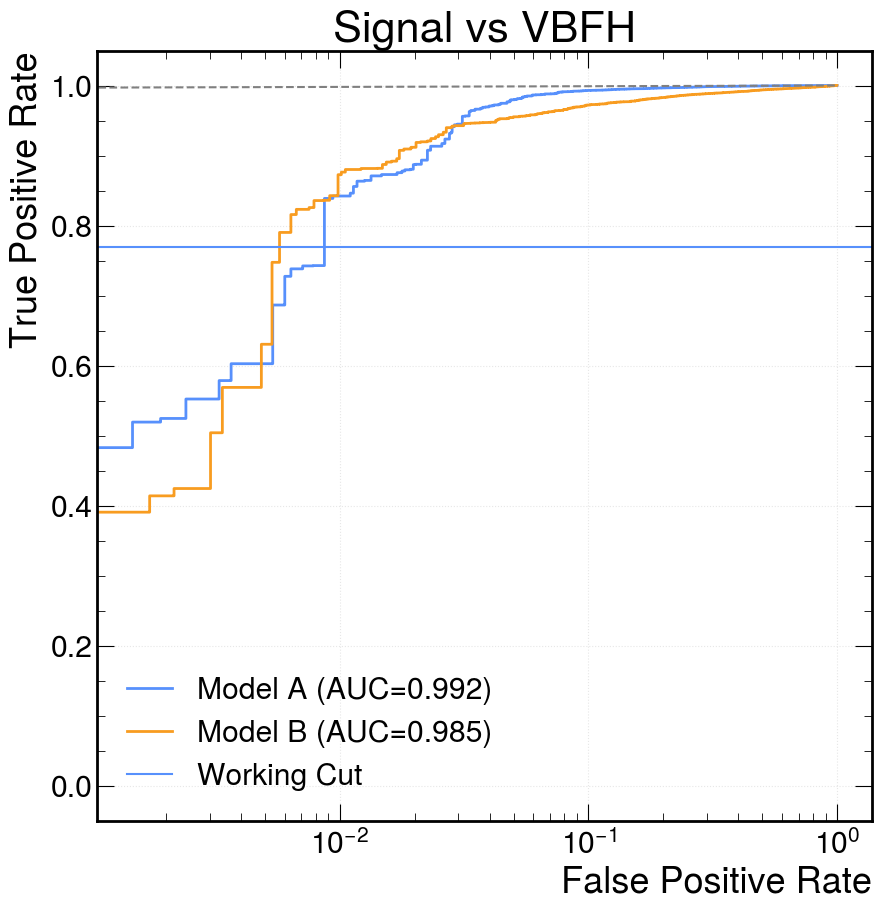

In [63]:
plot_roc_compare_per_type(
    df_eval,
    scoreA="score_A",
    scoreB="score_B",
    type_label_map=type_label_map,
    weight_col="balanced_Weight",
    use_abs_weight=True,
    logx=True   # physics更推荐 log FPR
)